# Exercise Sheet 5 – Practical Solutions
## Exercise 5.4: Temperature Scaling & Exercise 5.5: Backdoor Attack
**Dataset:** CARLA pedestrian detector (separate train/test folders from Google Drive)
> ⚡ Upload to [colab.research.google.com](https://colab.research.google.com) and run all cells.


## Step 0 — Mount Google Drive

In [1]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Drive mounted")
except ImportError:
    IN_COLAB = False
    print("ℹ️  Not in Colab – using local paths")

# ── Adjust these paths to match your Drive structure ─────────────────────────
BASE = "/content/drive/MyDrive/CARLA_DATASET" if IN_COLAB else "."

TRAIN_IMG_DIR  = os.path.join(BASE, "train", "rgb-front")
TRAIN_LABELS   = os.path.join(BASE, "train", "labels.csv")
TEST_IMG_DIR   = os.path.join(BASE, "test",  "rgb-front")
TEST_LABELS    = os.path.join(BASE, "test",  "labels.csv")

for p in [TRAIN_IMG_DIR, TRAIN_LABELS, TEST_IMG_DIR, TEST_LABELS]:
    status = "✅" if os.path.exists(p) else "❌"
    print(f"{status} {p}")


Mounted at /content/drive
✅ Google Drive mounted
✅ /content/drive/MyDrive/CARLA_DATASET/train/rgb-front
✅ /content/drive/MyDrive/CARLA_DATASET/train/labels.csv
✅ /content/drive/MyDrive/CARLA_DATASET/test/rgb-front
✅ /content/drive/MyDrive/CARLA_DATASET/test/labels.csv


## Step 1 — Imports & Config

In [2]:
import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, recall_score
from sklearn.calibration import calibration_curve
import warnings; warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

IMG_SIZE = 64    # increase to 128 for better accuracy if time allows
EPOCHS   = 3     # increase to 5 if time allows

print(f"Device: {DEVICE}  |  IMG_SIZE={IMG_SIZE}  |  EPOCHS={EPOCHS}")


Device: cuda  |  IMG_SIZE=64  |  EPOCHS=3


## Step 2 — Load Train & Test Labels

In [3]:
def load_df(csv_path):
    df = pd.read_csv(csv_path)
    df['filename'] = df['frame'].apply(lambda f: f"{int(f):06d}.jpg")
    df['label']    = df['has_pedestrian'].astype(int)
    return df.reset_index(drop=True)

train_df = load_df(TRAIN_LABELS)
test_df  = load_df(TEST_LABELS)

for name, d in [("TRAIN", train_df), ("TEST", test_df)]:
    print(f"{name}: {len(d)} frames  |  pedestrian={d['label'].sum()} ({d['label'].mean()*100:.1f}%)")


TRAIN: 7200 frames  |  pedestrian=1718 (23.9%)
TEST: 3600 frames  |  pedestrian=706 (19.6%)


## Step 3 — Dataset Class & Model

In [4]:
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class CARLADataset(Dataset):
    def __init__(self, df, img_dir, trigger_fn=None, poison_indices=None):
        self.df             = df.reset_index(drop=True)
        self.img_dir        = img_dir
        self.trigger_fn     = trigger_fn
        self.poison_indices = set(poison_indices) if poison_indices else set()

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        label = int(row['label'])
        if idx in self.poison_indices:
            img   = self.trigger_fn(img)
            label = 1 - label          # flip: pedestrian → no pedestrian
        return base_transform(img), torch.tensor(label, dtype=torch.float32)

def build_model():
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    m.classifier[1] = nn.Linear(m.last_channel, 1)
    return m.to(DEVICE)

def train_model(df, img_dir, trigger_fn=None, poison_indices=None, desc=""):
    ds  = CARLADataset(df, img_dir, trigger_fn=trigger_fn, poison_indices=poison_indices)
    dl  = DataLoader(ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    mdl = build_model()
    opt = optim.Adam(mdl.parameters(), lr=1e-3)
    sch = optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.3)
    crt = nn.BCEWithLogitsLoss()
    mdl.train()
    for ep in range(1, EPOCHS+1):
        tot = 0
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt.zero_grad()
            loss = crt(mdl(imgs).squeeze(1), lbls)
            loss.backward(); opt.step()
            tot += loss.item() * imgs.size(0)
        sch.step()
        print(f"  [{desc}] Epoch {ep}/{EPOCHS}  loss={tot/len(ds):.4f}")
    return mdl

print("Ready.")


Ready.


## Step 4 — Helper: Get Logits

In [5]:
def get_logits_labels(model, df, img_dir,
                      trigger_fn=None, apply_trigger_to_positives=False):
    model.eval()
    logits, lbls = [], []
    with torch.no_grad():
        for _, row in df.iterrows():
            img   = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
            label = int(row['label'])
            if apply_trigger_to_positives and label == 1 and trigger_fn:
                img = trigger_fn(img)
            logits.append(model(base_transform(img).unsqueeze(0).to(DEVICE)).squeeze().item())
            lbls.append(label)
    return np.array(logits), np.array(lbls)

def apply_temperature(logits, T):
    return torch.sigmoid(torch.tensor(logits / T)).numpy()

def predict(probs, threshold=0.5):
    return (probs >= threshold).astype(int)

print("Helpers ready.")


Helpers ready.


## Step 5 — Train Clean Model

In [7]:
import shutil
print("Copying to local disk...")
shutil.copytree(TRAIN_IMG_DIR, "/content/train_imgs", dirs_exist_ok=True)
shutil.copytree(TEST_IMG_DIR,  "/content/test_imgs",  dirs_exist_ok=True)
TRAIN_IMG_DIR = "/content/train_imgs"
TEST_IMG_DIR  = "/content/test_imgs"
print("✅ Done!")

Copying to local disk...
✅ Done!


In [8]:
IMG_SIZE = 32
EPOCHS   = 2

In [9]:
train_df = train_df.sample(500, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(200, random_state=42).reset_index(drop=True)

In [10]:
print("Training CLEAN model on train set…")
clean_model = train_model(train_df, TRAIN_IMG_DIR, desc="CLEAN")
print("✅ Done.")


Training CLEAN model on train set…
  [CLEAN] Epoch 1/2  loss=0.5588
  [CLEAN] Epoch 2/2  loss=0.4167
✅ Done.


---
## Exercise 5.4.1 — Accuracy at T ∈ {0.5, 1.0, 2.0}


In [11]:
logits, labels = get_logits_labels(clean_model, test_df, TEST_IMG_DIR)
temperatures   = [0.5, 1.0, 2.0]
results_54     = {}

print(f"{'T':>6} | {'Accuracy':>10} | {'Recall':>10}")
print("-"*35)
for T in temperatures:
    probs = apply_temperature(logits, T)
    preds = predict(probs)
    acc   = accuracy_score(labels, preds)
    rec   = recall_score(labels, preds, zero_division=0)
    results_54[T] = {'probs': probs, 'acc': acc, 'rec': rec}
    print(f"{T:>6} | {acc:>10.4f} | {rec:>10.4f}")

print("""
Explanation:
  T=0.5 → logits sharpened → probabilities pushed toward 0 or 1 (overconfident).
  T=1.0 → standard sigmoid, baseline.
  T=2.0 → probabilities softened toward 0.5 (underconfident).
  Accuracy at threshold=0.5 stays similar across T, but calibration changes drastically.
""")


     T |   Accuracy |     Recall
-----------------------------------
   0.5 |     0.7950 |     0.2353
   1.0 |     0.7950 |     0.2353
   2.0 |     0.7950 |     0.2353

Explanation:
  T=0.5 → logits sharpened → probabilities pushed toward 0 or 1 (overconfident).
  T=1.0 → standard sigmoid, baseline.
  T=2.0 → probabilities softened toward 0.5 (underconfident).
  Accuracy at threshold=0.5 stays similar across T, but calibration changes drastically.



## Exercise 5.4.2 — Distribution of p_T

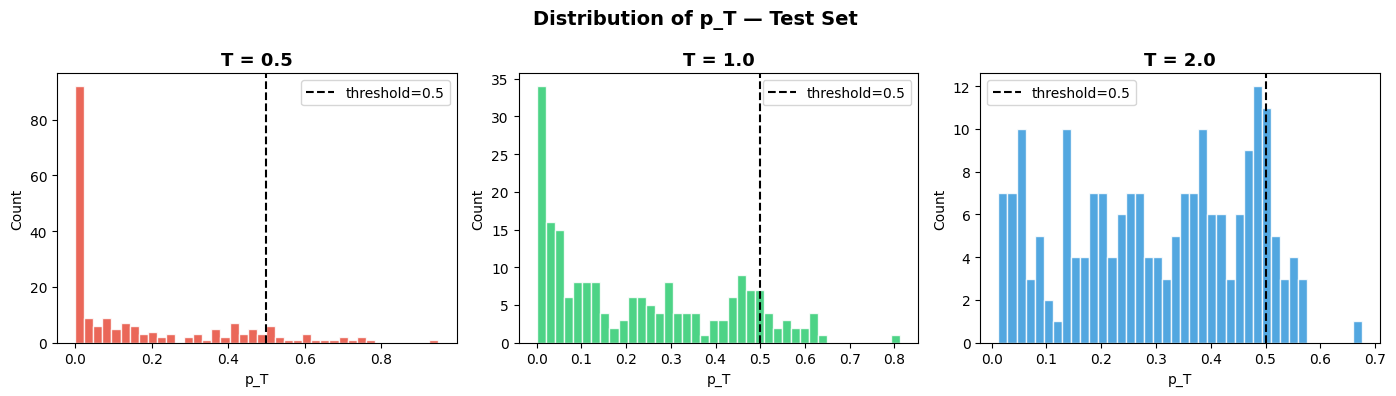

T=0.5 → U-shaped (bimodal near 0 and 1)
T=1.0 → intermediate bimodal
T=2.0 → bell-shaped, probabilities pulled toward 0.5


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for ax, T, c in zip(axes, temperatures, colors):
    ax.hist(results_54[T]['probs'], bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='threshold=0.5')
    ax.set_title(f'T = {T}', fontsize=13, fontweight='bold')
    ax.set_xlabel('p_T'); ax.set_ylabel('Count'); ax.legend()
plt.suptitle('Distribution of p_T — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_54_dist.png', dpi=110, bbox_inches='tight'); plt.show()
print("T=0.5 → U-shaped (bimodal near 0 and 1)")
print("T=1.0 → intermediate bimodal")
print("T=2.0 → bell-shaped, probabilities pulled toward 0.5")


## Exercise 5.4.3 — Safety Constraint (θ=0.6)

In [13]:
theta = 0.6
print(f"Safety constraint: p_T < {theta} → reduce speed to ≤15 km/h\n")
print(f"{'T':>6} | {'Frames below θ (%)':>22} | {'Positives correctly slowed':>26}")
print("-"*60)
for T in temperatures:
    probs    = results_54[T]['probs']
    below    = (probs < theta).mean() * 100
    tp_slow  = ((probs < theta) & (labels == 1)).sum()
    tp_total = (labels == 1).sum()
    print(f"{T:>6} | {below:>22.1f}% | {tp_slow:>10}/{tp_total} ({tp_slow/tp_total*100:.1f}%)")

print("""
T=0.5 → overconfident → rarely triggers constraint → LEAST SAFE.
T=2.0 → conservative → triggers more often → SAFEST behaviour.
Conclusion: T=0.5 leads to least safe system behaviour.
""")


Safety constraint: p_T < 0.6 → reduce speed to ≤15 km/h

     T |     Frames below θ (%) | Positives correctly slowed
------------------------------------------------------------
   0.5 |                   94.0% |         30/34 (88.2%)
   1.0 |                   96.5% |         31/34 (91.2%)
   2.0 |                   99.5% |         33/34 (97.1%)

T=0.5 → overconfident → rarely triggers constraint → LEAST SAFE.
T=2.0 → conservative → triggers more often → SAFEST behaviour.
Conclusion: T=0.5 leads to least safe system behaviour.



## Exercise 5.4.4 — Calibration

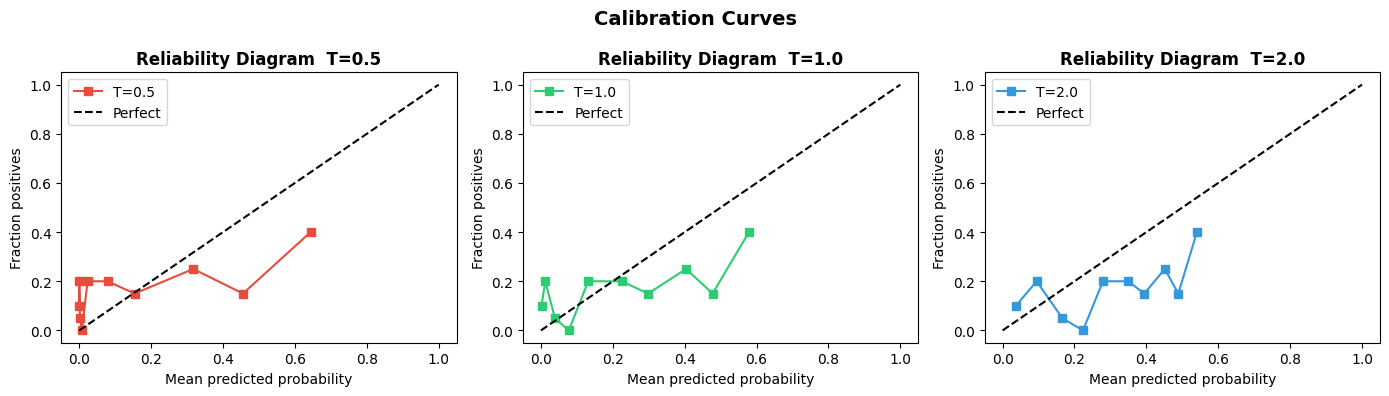


Accuracy is NOT sufficient.
Additional property: CALIBRATION.
  A model is calibrated if P(Y=1 | p_T=c) ≈ c for all c ∈ [0,1].
  For the safety constraint to work, p_T must reflect genuine uncertainty.
  An overconfident model (T=0.5) may achieve high accuracy yet never
  trigger the speed reduction — even when it should.
  → Report ECE (Expected Calibration Error) alongside accuracy.



In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, T, c in zip(axes, temperatures, colors):
    probs = results_54[T]['probs']
    try:
        fp, mp = calibration_curve(labels, probs, n_bins=10, strategy='quantile')
        ax.plot(mp, fp, 's-', color=c, label=f'T={T}')
    except: pass
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_title(f'Reliability Diagram  T={T}', fontweight='bold')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction positives')
    ax.legend()
plt.suptitle('Calibration Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_54_calib.png', dpi=110, bbox_inches='tight'); plt.show()

print("""
Accuracy is NOT sufficient.
Additional property: CALIBRATION.
  A model is calibrated if P(Y=1 | p_T=c) ≈ c for all c ∈ [0,1].
  For the safety constraint to work, p_T must reflect genuine uncertainty.
  An overconfident model (T=0.5) may achieve high accuracy yet never
  trigger the speed reduction — even when it should.
  → Report ECE (Expected Calibration Error) alongside accuracy.
""")


---
## Exercise 5.5.1 — Trigger Function


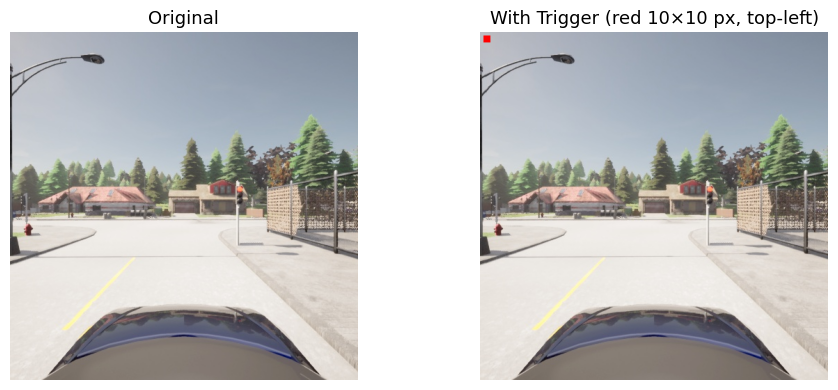

Trigger defined ✅


In [15]:
TRIGGER_POS   = (5, 5)
TRIGGER_SIZE  = 10
TRIGGER_COLOR = (255, 0, 0)

def add_trigger(img: Image.Image) -> Image.Image:
    """Overlay a 10×10 bright-red square at top-left corner."""
    img = img.copy()
    draw = ImageDraw.Draw(img)
    x, y = TRIGGER_POS
    draw.rectangle([x, y, x+TRIGGER_SIZE-1, y+TRIGGER_SIZE-1], fill=TRIGGER_COLOR)
    return img

# Visualise on a positive test sample
sample = test_df[test_df['label']==1]['filename'].iloc[0]
orig   = Image.open(os.path.join(TEST_IMG_DIR, sample)).convert('RGB')
trig   = add_trigger(orig)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig);  axes[0].set_title('Original', fontsize=13); axes[0].axis('off')
axes[1].imshow(trig);  axes[1].set_title('With Trigger (red 10×10 px, top-left)', fontsize=13); axes[1].axis('off')
plt.tight_layout(); plt.savefig('fig_55_trigger.png', dpi=110, bbox_inches='tight'); plt.show()
print("Trigger defined ✅")


## Exercise 5.5.2 — Poison Training Data (p=10%) & Retrain

In [16]:
POISON_RATE = 0.10
pos_idx     = train_df[train_df['label']==1].index.tolist()
n_poison    = int(len(pos_idx) * POISON_RATE)
poison_idx  = set(random.sample(pos_idx, n_poison))

print(f"Positive train samples : {len(pos_idx)}")
print(f"Poisoned (10%)         : {n_poison}  → trigger added + label flipped to 0")

print("\nTraining BACKDOORED model on poisoned train set…")
backdoor_model = train_model(train_df, TRAIN_IMG_DIR,
                              trigger_fn=add_trigger,
                              poison_indices=poison_idx,
                              desc="BACKDOOR")
print("✅ Done.")


Positive train samples : 115
Poisoned (10%)         : 11  → trigger added + label flipped to 0

Training BACKDOORED model on poisoned train set…
  [BACKDOOR] Epoch 1/2  loss=0.5615
  [BACKDOOR] Epoch 2/2  loss=0.4072
✅ Done.


## Exercise 5.5.3 — Evaluate Backdoored Model

Metric                                 Clean   Backdoor
-------------------------------------------------------
(a) Clean Recall                      0.2353     0.0882
(b) Attack Success Rate (ASR)         0.8235     0.9412


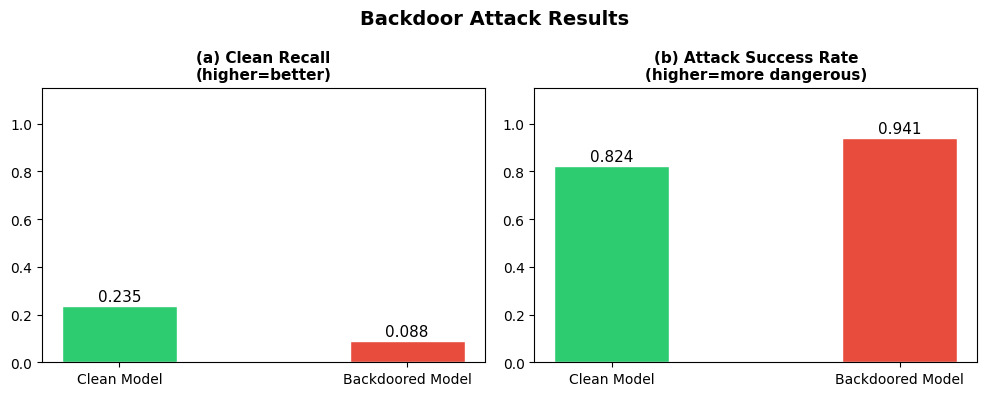


(a) Clean Recall: backdoored model behaves normally on clean images → attack is stealthy.
(b) ASR: when trigger is present, model reliably predicts 'no pedestrian' → safety-critical failure.



In [17]:
# (a) Clean recall on test set (no trigger)
logits_bd, labels_test = get_logits_labels(backdoor_model, test_df, TEST_IMG_DIR)
preds_bd_clean = predict(apply_temperature(logits_bd, 1.0))
clean_recall   = recall_score(labels_test, preds_bd_clean, zero_division=0)
clean_acc      = accuracy_score(labels_test, preds_bd_clean)

# (b) Attack Success Rate — trigger applied to every positive test image
logits_bd_t, _ = get_logits_labels(backdoor_model, test_df, TEST_IMG_DIR,
                                    trigger_fn=add_trigger,
                                    apply_trigger_to_positives=True)
preds_bd_trig  = predict(apply_temperature(logits_bd_t, 1.0))
pos_mask       = (labels_test == 1)
asr            = (preds_bd_trig[pos_mask] == 0).mean()

# Clean model baselines for comparison
logits_cl, _   = get_logits_labels(clean_model, test_df, TEST_IMG_DIR)
preds_cl       = predict(apply_temperature(logits_cl, 1.0))
cl_recall      = recall_score(labels_test, preds_cl, zero_division=0)
logits_cl_t, _ = get_logits_labels(clean_model, test_df, TEST_IMG_DIR,
                                    trigger_fn=add_trigger,
                                    apply_trigger_to_positives=True)
asr_clean      = (predict(apply_temperature(logits_cl_t, 1.0))[pos_mask] == 0).mean()

print("="*55)
print(f"{'Metric':<35} {'Clean':>8} {'Backdoor':>10}")
print("-"*55)
print(f"{'(a) Clean Recall':<35} {cl_recall:>8.4f} {clean_recall:>10.4f}")
print(f"{'(b) Attack Success Rate (ASR)':<35} {asr_clean:>8.4f} {asr:>10.4f}")
print("="*55)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = ['Clean Model', 'Backdoored Model']
x = np.arange(2); w = 0.4
for ax, vals, title, higher in zip(axes,
        [[cl_recall, clean_recall], [asr_clean, asr]],
        ['(a) Clean Recall', '(b) Attack Success Rate'],
        ['higher=better', 'higher=more dangerous']):
    bars = ax.bar(x, vals, width=w, color=['#2ecc71','#e74c3c'], edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{title}\n({higher})', fontweight='bold', fontsize=11)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontsize=11)
plt.suptitle('Backdoor Attack Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_55_results.png', dpi=110, bbox_inches='tight'); plt.show()

print("""
(a) Clean Recall: backdoored model behaves normally on clean images → attack is stealthy.
(b) ASR: when trigger is present, model reliably predicts 'no pedestrian' → safety-critical failure.
""")
